# What a markdown table cannot carry

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/automation-suite/markdown-tabler/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=automation-suite/markdown-tabler/demo.ipynb)

**Day 140 - automation-suite.** Turning a DataFrame into a markdown table is a one-liner. The
one-liner is also a lossy encoder, and the GitHub Flavored Markdown table extension has no error
state to tell you so: it truncates the row that is one cell too wide, trims the cell whose meaning
is its indentation, and italicises the identifier with an underscore at each end. All three are
specified behaviour. None of them produce a warning.

This notebook renders a small lint export - the kind of table that gets pasted into a pull request
comment - and then parses the rendered table back with a real GFM parser to show which cells did
not survive the trip.

1. Display width: why `len()` is the wrong ruler for padding
2. The pipe, and the escape that works everywhere except one place
3. Emphasis: which identifiers lose their underscores
4. Whitespace and line breaks: the two things with no escape at all
5. The ragged row, reshaped in silence
6. Render, parse back, compare - the audit against a parser
7. Try your own

## Setup

Everything below is self-contained - the core logic is duplicated here rather than imported, so the
notebook runs on Colab or Binder with nothing checked out. `markdown-it-py` is the GFM parser used
for the round trips; if it is missing the notebook still runs and skips those comparisons.

In [1]:
from __future__ import annotations

import re
import unicodedata
from dataclasses import dataclass
from typing import Dict, List, Optional, Sequence, Tuple

try:
    from markdown_it import MarkdownIt
    MD = MarkdownIt("gfm-like")
    MD_NO_HTML = MarkdownIt("gfm-like", {"html": False})
    HAVE_PARSER = True
except ImportError:
    HAVE_PARSER = False
    print("markdown-it-py not installed - round-trip cells will be skipped")

LOSS, PORTABILITY, COSMETIC = "LOSS", "PORTABILITY", "COSMETIC"
SEVERITY_ORDER = {LOSS: 0, PORTABILITY: 1, COSMETIC: 2}

_TAG = re.compile(r"<[^>]+>")
_ROW = re.compile(r"<tr>(.*?)</tr>", re.S)
_CELL = re.compile(r"<t[hd][^>]*>(.*?)</t[hd]>", re.S)

import html as _html

def parse_back(markdown, allow_html=True, raw=False):
    """Render markdown to HTML and read the table back as rows of cell text."""
    out = (MD if allow_html else MD_NO_HTML).render(markdown)
    rows = []
    for row_html in _ROW.findall(out):
        cells = []
        for cell in _CELL.findall(row_html):
            cells.append(cell.strip() if raw else _html.unescape(_TAG.sub("", cell)).strip())
        rows.append(cells)
    return rows

def one_cell(source, **kw):
    """Put one string in a one-column table and read back what the reader sees."""
    return parse_back("| c |\n| --- |\n| %s |" % source, **kw)[1][0]

print("ready")

ready


## 1. Display width: `len()` is the wrong ruler

Padding cells to a common width does not change what renders - HTML does not care about the
whitespace. It changes whether the person reading the raw markdown in a pull request diff can see
the columns at all.

`len()` counts code points. A monospace font counts columns. The two disagree for CJK (two columns
per glyph), for combining marks (zero columns), and for emoji. So the rows that drift out of
alignment are exactly the ones a Western-locale test fixture never contains.

In [2]:
ZERO_WIDTH = {"Mn", "Me", "Cf"}

def display_width(text: str, ambiguous_wide: bool = False) -> int:
    total = 0
    for ch in text:
        if ch == "\u200d" or unicodedata.category(ch) in ZERO_WIDTH:
            continue
        eaw = unicodedata.east_asian_width(ch)
        if eaw in ("W", "F"):
            total += 2
        elif eaw == "A":
            total += 2 if ambiguous_wide else 1
        else:
            total += 1
    return total

def pad(text: str, width: int, align: str = "left") -> str:
    gap = max(0, width - display_width(text))
    if align == "right":
        return " " * gap + text
    if align == "center":
        return " " * (gap // 2) + text + " " * (gap - gap // 2)
    return text + " " * gap

samples = ["Ana Ruiz", "\u9648\u4f1f", "\U0001f6a6 flag", "caf\u00e9", "cafe\u0301"]
notes = ["ASCII", "2 CJK glyphs", "emoji + text", "precomposed e-acute", "e + combining acute"]

print("%-16s %-8s %-8s %s" % ("value", "len()", "columns", "note"))
print("-" * 62)
for s, n in zip(samples, notes):
    flag = "  <-- disagree" if len(s) != display_width(s) else ""
    print("%-16s %-8d %-8d %s%s" % (repr(s)[:16], len(s), display_width(s), n, flag))

value            len()    columns  note
--------------------------------------------------------------
'Ana Ruiz'       8        8        ASCII
'陈伟'             2        4        2 CJK glyphs  <-- disagree
'🚦 flag'         6        7        emoji + text  <-- disagree
'café'           4        4        precomposed e-acute
'café'          5        4        e + combining acute  <-- disagree


Three of the five disagree. Here is what that does to a table's source - the same two columns,
padded by `len()` and then by display width:

In [3]:
rows = [["\u9648\u4f1f", "1"], ["Ana Ruiz", "2"], ["\U0001f6a6 flag", "3"]]

print("padded by len()  -- the pipes drift:\n")
w = max(len(r[0]) for r in rows)
for r in rows:
    print("    | " + r[0] + " " * (w - len(r[0])) + " | " + r[1] + " |")

print("\npadded by display width -- the pipes line up:\n")
w = max(display_width(r[0]) for r in rows)
for r in rows:
    print("    | " + pad(r[0], w) + " | " + r[1] + " |")

print("\n(In a proportional font this cell renders both blocks unevenly. Copy them into a"
      "\n monospace editor -- that is where the difference is visible, and where the diff lives.)")

padded by len()  -- the pipes drift:

    | 陈伟       | 1 |
    | Ana Ruiz | 2 |
    | 🚦 flag   | 3 |

padded by display width -- the pipes line up:

    | 陈伟     | 1 |
    | Ana Ruiz | 2 |
    | 🚦 flag  | 3 |

(In a proportional font this cell renders both blocks unevenly. Copy them into a
 monospace editor -- that is where the difference is visible, and where the diff lives.)


## 2. The pipe, and the escape that fails in one place

A pipe inside a cell splits the row unless it is escaped. Two escapes get recommended: the
backslash `\|` and the HTML entity `&#124;`. Both pass the obvious test. Only one of them survives
a code span, because entity references are not recognised inside backticks - so `&#124;` stops
being a pipe and becomes six visible characters.

This matters more than it sounds: a code span is exactly where a pipe usually turns up. Regexes,
shell pipelines, union types.

In [4]:
if HAVE_PARSER:
    cases = [
        ("plain text",         "a\\|b",   "a&#124;b"),
        ("inside a code span", "`a\\|b`", "`a&#124;b`"),
    ]
    print("%-20s %-16s %s" % ("context", "backslash \\|", "entity &#124;"))
    print("-" * 62)
    for label, with_escape, with_entity in cases:
        print("%-20s %-16s %s" % (label, repr(one_cell(with_escape)), repr(one_cell(with_entity))))
    print("-" * 62)
    print("The bottom-right cell is the failure: six characters where a pipe was meant.")
else:
    print("skipped - needs markdown-it-py")

context              backslash \|     entity &#124;
--------------------------------------------------------------
plain text           'a|b'            'a|b'
inside a code span   'a|b'            'a&#124;b'
--------------------------------------------------------------
The bottom-right cell is the failure: six characters where a pipe was meant.


So the escaper always uses the backslash, and the auditor raises a finding when the *input* already
contains the entity form inside backticks - because at that point somebody has already tried to fix
this and the fix does not work.

In [5]:
PIPE = re.compile(r"(?<!\\)\|")
ENTITY_PIPE = re.compile(r"&#(?:124|x7c|X7C);")
CODE_SPAN = re.compile(r"`+[^`]*`+")

STAR_EMPHASIS = re.compile(r"\*(?=\S)[^*]*\*")
UNDERSCORE_EMPHASIS = re.compile(r"(?:^|(?<=[\s(\[]))_(?=\S).*_(?=$|[\s.,;:!?)\]])")

def emphasis_spans(text: str) -> List[str]:
    masked = CODE_SPAN.sub(lambda m: "\x00" * len(m.group(0)), text)
    return ([m.group(0) for m in STAR_EMPHASIS.finditer(masked)]
            + [m.group(0) for m in UNDERSCORE_EMPHASIS.finditer(masked)])

def escape_emphasis_runs(text: str) -> str:
    marks = set()
    masked = CODE_SPAN.sub(lambda m: "\x00" * len(m.group(0)), text)
    for rx in (STAR_EMPHASIS, UNDERSCORE_EMPHASIS):
        for m in rx.finditer(masked):
            i = m.start()
            while i < m.end() and text[i] in "*_":
                marks.add(i); i += 1
            j = m.end() - 1
            while j >= m.start() and text[j] in "*_":
                marks.add(j); j -= 1
    return "".join(("\\" + c) if (i in marks and c in "*_") else c for i, c in enumerate(text))

def escape_cell(text: str, newline: str = "br", escape_emphasis: bool = False) -> str:
    out = text
    if newline == "br":
        out = re.sub(r"\r\n|\r|\n", "<br>", out)
    elif newline == "space":
        out = re.sub(r"\s*(?:\r\n|\r|\n)\s*", " ", out)
    elif newline == "strip":
        out = re.split(r"\r\n|\r|\n", out)[0]
    out = PIPE.sub(r"\\|", out)
    if escape_emphasis and emphasis_spans(out):
        out = escape_emphasis_runs(out)
    return out

print(escape_cell("a|b"))
print(escape_cell("`a|b`"))
print(escape_cell("retry\nthen alert"))

a\|b
`a\|b`
retry<br>then alert


## 3. Emphasis eats identifiers

A column of column-names or config keys meets markdown's inline emphasis rules. `_` opens emphasis
only at a word boundary; `*` opens it almost anywhere. So `snake_case_ok` is safe by design - that
carve-out exists for identifiers - and `_id_field_` is not.

The italic is not the problem. The lost characters are: the reader sees `id_field`, and the
underscores that told them it was a private field are gone.

In [6]:
if HAVE_PARSER:
    ids = ["snake_case_ok", "a_b", "_id_field_", "__dunder__", "*star*", "2*3*4"]
    print("%-16s %-16s %-9s %s" % ("written", "reader sees", "verdict", "with escaping"))
    print("-" * 66)
    for s in ids:
        plain = one_cell(escape_cell(s))
        fixed = one_cell(escape_cell(s, escape_emphasis=True))
        verdict = "same" if plain == s else "-%d chars" % (len(s) - len(plain))
        print("%-16s %-16s %-9s %s" % (s, repr(plain), verdict, repr(fixed)))
    print("-" * 66)
    print("escape_emphasis=True recovers all four, at the cost of backslashes in the source.")
else:
    print("skipped - needs markdown-it-py")

written          reader sees      verdict   with escaping
------------------------------------------------------------------
snake_case_ok    'snake_case_ok'  same      'snake_case_ok'
a_b              'a_b'            same      'a_b'
_id_field_       'id_field'       -2 chars  '_id_field_'
__dunder__       'dunder'         -4 chars  '__dunder__'
*star*           'star'           -2 chars  '*star*'
2*3*4            '234'            -2 chars  '2*3*4'
------------------------------------------------------------------
escape_emphasis=True recovers all four, at the cost of backslashes in the source.


## 4. The two things with no escape at all

**Leading and trailing whitespace** is trimmed by the renderer. A linter reporting `'  indent'` and
one reporting `'indent'` produce the same table. There is no escape for this; the only faithful
container is a code span, which changes how the cell looks.

**A line break** cannot be in a table row, because a row is a line. The three options are an HTML
`<br>`, a flatten, or a truncation - and the `<br>` is the one that depends on the renderer having
inline HTML enabled, which docs pipelines and comment sanitisers routinely turn off.

In [7]:
if HAVE_PARSER:
    print("whitespace:\n")
    for s in ["  indent", "indent", "trail  ", "\tab"]:
        got = one_cell(escape_cell(s))
        print("    %-12s -> %-12s %s" % (repr(s), repr(got), "same" if got == s else "CHANGED"))
    span_html = MD.render("| c |\n| --- |\n| `  indent` |").split("<td>")[1].split("</td>")[0]
    print("\n    the one faithful container is a code span, which keeps the spaces")
    print("    and changes the formatting:  %s" % span_html)

    print("\n\nline breaks (raw HTML, because a rendered <br> and the literal text"
          "\nread back identically once tags are stripped):\n")
    print("    %-8s %-24s %-24s %s" % ("policy", "source", "html enabled", "html disabled"))
    for policy in ("br", "space", "strip"):
        cell = escape_cell("retry\nthen alert", newline=policy)
        print("    %-8s %-24s %-24s %s" % (
            policy, repr(cell),
            one_cell(cell, raw=True), one_cell(cell, allow_html=False, raw=True)))
    print("\n    Under 'br' with HTML off, four visible characters land mid-sentence.")
else:
    print("skipped - needs markdown-it-py")

whitespace:

    '  indent'   -> 'indent'     CHANGED
    'indent'     -> 'indent'     same
    'trail  '    -> 'trail'      CHANGED
    '\tab'       -> 'ab'         CHANGED

    the one faithful container is a code span, which keeps the spaces
    and changes the formatting:  <code>  indent</code>


line breaks (raw HTML, because a rendered <br> and the literal text
read back identically once tags are stripped):

    policy   source                   html enabled             html disabled
    br       'retry<br>then alert'    retry<br>then alert      retry&lt;br&gt;then alert
    space    'retry then alert'       retry then alert         retry then alert
    strip    'retry'                  retry                    retry

    Under 'br' with HTML off, four visible characters land mid-sentence.


## 5. The ragged row

GFM specifies the reshape precisely: a row with more cells than the header has the excess
**ignored**, a row with fewer has empty cells **inserted**. Both are silent. A widened export drops
its new last column, and nobody sees an error - the table just renders.

This is the one failure a round trip can never show you, because the content never enters the
table. It has to be caught before rendering.

In [8]:
if HAVE_PARSER:
    md_src = "| a | b |\n| --- | --- |\n| 1 | 2 | 3 |\n| 4 |"
    print("source:")
    for line in md_src.splitlines():
        print("    " + line)
    print("\nparsed back:")
    for r in parse_back(md_src):
        print("    " + repr(r))
    print("\n'3' is gone. The empty cell in the last row is indistinguishable from a real blank.")
else:
    print("skipped - needs markdown-it-py")

source:
    | a | b |
    | --- | --- |
    | 1 | 2 | 3 |
    | 4 |

parsed back:
    ['a', 'b']
    ['1', '2']
    ['4', '']

'3' is gone. The empty cell in the last row is indistinguishable from a real blank.


## 6. The renderer, and the audit

Now the whole thing: render the table, and separately return the list of cells whose content did
not survive. Rendering never raises - the audit is the channel.

Severities are about consequence, not about how unusual the input is:

| severity | meaning |
| :--- | :--- |
| `LOSS` | the rendered table does not contain what you put in |
| `PORTABILITY` | it renders here, but not under every conforming renderer |
| `COSMETIC` | the output is right; the markdown source is misaligned |

In [9]:
@dataclass(frozen=True)
class Finding:
    code: str
    severity: str
    row: int
    column: str
    detail: str
    @property
    def where(self):
        return "header" if self.row < 0 else "row %d" % self.row

def audit_cell(text, row, column, newline="br", escape_emphasis=False):
    out = []
    def add(code, sev, detail):
        out.append(Finding(code, sev, row, column, detail))
    if "\n" in text or "\r" in text:
        n = len(re.split(r"\r\n|\r|\n", text))
        if newline == "br":
            add("NEWLINE", PORTABILITY, "%d lines joined with <br> (an HTML tag)" % n)
        else:
            add("NEWLINE", LOSS, "%d lines flattened; the breaks are gone" % n)
    if ENTITY_PIPE.search(text) and any(
            ENTITY_PIPE.search(m.group(0)) for m in CODE_SPAN.finditer(text)):
        add("ENTITY_IN_CODE", LOSS, "&#124; in a code span renders as six characters")
    if text != text.strip():
        add("EDGE_SPACE", LOSS, "edge whitespace is trimmed and is not representable")
    spans = emphasis_spans(text)
    if spans:
        add("EMPHASIS", COSMETIC if escape_emphasis else LOSS,
            "%s %s" % (", ".join(sorted(set(spans))[:2]),
                       "escaped" if escape_emphasis else "becomes italic, delimiters eaten"))
    if text.endswith("\\") and not text.endswith("\\\\"):
        add("BACKSLASH_END", PORTABILITY, "trailing backslash against the closing pipe")
    if display_width(text) != len(text):
        add("WIDE_GLYPH", COSMETIC,
            "%d code points, %d columns - len() padding misaligns" % (len(text), display_width(text)))
    if "|" in text:
        add("PIPE", COSMETIC, "%d pipe(s) escaped" % text.count("|"))
    return out

NUMERIC = re.compile(r"^[-+(]?\s*[$\u00a3\u20ac\u00a5]?\s*\d[\d,_ ]*(?:\.\d+)?\s*%?\)?$")

def infer_alignment(values):
    seen = [v.strip() for v in values if v.strip()]
    return "right" if seen and all(NUMERIC.match(v) for v in seen) else "left"

def delimiter_cell(align, width):
    if align == "right":
        return "-" * max(3, width - 1) + ":"
    return ":" + "-" * max(3, width - 1)

def render(rows, headers, newline="br", escape_emphasis=False):
    head = [str(h) for h in headers]
    ncols, findings, grid = len(head), [], []
    for r_idx, raw in enumerate(rows):
        cells = ["" if c is None else ("%g" % c if isinstance(c, float) else str(c)) for c in raw]
        if len(cells) > ncols:
            findings.append(Finding("RAGGED_EXTRA", LOSS, r_idx, head[-1],
                "%d cell(s) dropped by the renderer with no warning: %s"
                % (len(cells) - ncols, ", ".join(repr(d) for d in cells[ncols:]))))
            cells = cells[:ncols]
        elif len(cells) < ncols:
            findings.append(Finding("RAGGED_SHORT", PORTABILITY, r_idx, head[len(cells)],
                "%d empty cell(s) inserted" % (ncols - len(cells))))
            cells += [""] * (ncols - len(cells))
        for c_idx, cell in enumerate(cells):
            findings.extend(audit_cell(cell, r_idx, head[c_idx], newline, escape_emphasis))
        grid.append(cells)

    align = [infer_alignment([r[i] for r in grid]) for i in range(ncols)]
    eh = [escape_cell(h, newline, escape_emphasis) for h in head]
    eg = [[escape_cell(c, newline, escape_emphasis) for c in r] for r in grid]
    widths = [max([display_width(eh[i])] + [display_width(r[i]) for r in eg] + [3])
              for i in range(ncols)]
    line = lambda cs, al: "| " + " | ".join(pad(c, widths[i], al[i]) for i, c in enumerate(cs)) + " |"
    out = [line(eh, ["left"] * ncols),
           "| " + " | ".join(delimiter_cell(align[i], widths[i]) for i in range(ncols)) + " |"]
    out += [line(r, align) for r in eg]
    findings.sort(key=lambda f: (SEVERITY_ORDER[f.severity], f.row, f.code))
    return "\n".join(out), findings

print("renderer ready")

renderer ready


### The sample: a lint export headed for a pull request comment

Twelve findings from a code-review bot. Every hostile cell is content a real linter emits - a
regex, a code span, an owner name, an indented snippet. One row was written with six cells.

In [10]:
HEADERS = ["file", "pattern", "note", "hits", "owner"]
ROWS = [
    ["etl/load.py", "`a|b`", "alternation in a split", 12, "Chen Wei"],
    ["etl/load.py", "r'\\d+|\\w+'", "raw regex, two branches", 3, "Chen Wei"],
    ["api/auth.py", "`&#124;`", "entity used to escape a pipe", 1, "Ana Ruiz"],
    ["api/auth.py", "_id_field_", "leading+trailing underscore", 7, "Ana Ruiz"],
    ["jobs/nightly.py", "2*3*4", "star run in a literal", 2, "Ana Ruiz"],
    ["jobs/nightly.py", "retry\nthen alert", "two-line note", 4, "\u9648\u4f1f"],
    ["ui/table.tsx", "  indent", "leading spaces are the finding", 1, "Ana Ruiz"],
    ["ui/table.tsx", "C:\\path\\", "trailing backslash", 1, "Ana Ruiz"],
    ["ops/deploy.sh", "set -e", "no issue, control row", 0, "Ana Ruiz"],
    ["ops/deploy.sh", "grep -c", "ragged row follows", 5, "Ana Ruiz", "EXTRA-COLUMN"],
    ["docs/readme.md", "snake_case_ok", "underscores mid-word are safe", 9, "Ana Ruiz"],
    ["docs/readme.md", "emoji \U0001f6a6 label", "wide glyph in the cell", 6, "Ana Ruiz"],
]

table, findings = render(ROWS, HEADERS)
print(table)

| file            | pattern             | note                           | hits | owner    |
| :-------------- | :------------------ | :----------------------------- | ---: | :------- |
| etl/load.py     | `a\|b`              | alternation in a split         |   12 | Chen Wei |
| etl/load.py     | r'\d+\|\w+'         | raw regex, two branches        |    3 | Chen Wei |
| api/auth.py     | `&#124;`            | entity used to escape a pipe   |    1 | Ana Ruiz |
| api/auth.py     | _id_field_          | leading+trailing underscore    |    7 | Ana Ruiz |
| jobs/nightly.py | 2*3*4               | star run in a literal          |    2 | Ana Ruiz |
| jobs/nightly.py | retry<br>then alert | two-line note                  |    4 | 陈伟     |
| ui/table.tsx    |   indent            | leading spaces are the finding |    1 | Ana Ruiz |
| ui/table.tsx    | C:\path\            | trailing backslash             |    1 | Ana Ruiz |
| ops/deploy.sh   | set -e              | no issue, control row         

That table renders. It is also missing a cell, has an italicised identifier, a trimmed indent and
an entity that is not an entity - and nothing in the output says so. The audit does:

In [11]:
print("%-15s %-12s %-8s %-9s %s" % ("code", "severity", "where", "column", "detail"))
print("-" * 96)
for f in findings:
    print("%-15s %-12s %-8s %-9s %s" % (f.code, f.severity, f.where, f.column, f.detail[:44]))
print("-" * 96)
loss = [f for f in findings if f.severity == LOSS]
print("%d findings, %d of them LOSS. This table is not safe to paste as-is." % (len(findings), len(loss)))

code            severity     where    column    detail
------------------------------------------------------------------------------------------------
ENTITY_IN_CODE  LOSS         row 2    pattern   &#124; in a code span renders as six charact
EMPHASIS        LOSS         row 3    pattern   _id_field_ becomes italic, delimiters eaten
EMPHASIS        LOSS         row 4    pattern   *3* becomes italic, delimiters eaten
EDGE_SPACE      LOSS         row 6    pattern   edge whitespace is trimmed and is not repres
RAGGED_EXTRA    LOSS         row 9    owner     1 cell(s) dropped by the renderer with no wa
NEWLINE         PORTABILITY  row 5    pattern   2 lines joined with <br> (an HTML tag)
BACKSLASH_END   PORTABILITY  row 7    pattern   trailing backslash against the closing pipe
PIPE            COSMETIC     row 0    pattern   1 pipe(s) escaped
PIPE            COSMETIC     row 1    pattern   1 pipe(s) escaped
WIDE_GLYPH      COSMETIC     row 5    owner     2 code points, 4 columns - len() 

### Reconciling the audit against a parser

The claim worth checking: the audit is not a list of things that *might* go wrong, it is the diff a
parser would give you. So render, parse back, compare cell by cell, and see whether anything changed
that the audit did not name.

In [12]:
if HAVE_PARSER:
    back = parse_back(table)
    head, body = back[0], back[1:]
    predicted = {(f.row, f.column) for f in findings}
    changed, unpredicted = [], 0
    for i, row in enumerate(body):
        for j, got in enumerate(row):
            want = ROWS[i][j]
            want = "" if want is None else ("%g" % want if isinstance(want, float) else str(want))
            if got != want:
                ok = (i, head[j]) in predicted
                unpredicted += 0 if ok else 1
                codes = ", ".join(f.code for f in findings
                                  if (f.row, f.column) == (i, head[j]) and f.code != "WIDE_GLYPH")
                changed.append((i, head[j], want, got, codes or "(UNPREDICTED)"))

    total = len(ROWS) * len(HEADERS)
    print("%d of %d cells read back byte-identical. %d differ, %d unpredicted.\n"
          % (total - len(changed), total, len(changed), unpredicted))
    print("%-5s %-9s %-22s %-20s %s" % ("row", "column", "written", "read back", "audit said"))
    print("-" * 88)
    for i, col, w, g, codes in changed:
        print("%-5s %-9s %-22s %-20s %s" % (i, col, repr(w)[:22], repr(g)[:20], codes))
    print("-" * 88)
    print("Row 9's sixth cell is absent from this comparison because it is absent from the table.")
    print("RAGGED_EXTRA is the only record that it ever existed.")
else:
    print("skipped - needs markdown-it-py")

54 of 60 cells read back byte-identical. 6 differ, 0 unpredicted.

row   column    written                read back            audit said
----------------------------------------------------------------------------------------
0     pattern   '`a|b`'                'a|b'                PIPE
2     pattern   '`&#124;`'             '&#124;'             ENTITY_IN_CODE
3     pattern   '_id_field_'           'id_field'           EMPHASIS
4     pattern   '2*3*4'                '234'                EMPHASIS
5     pattern   'retry\nthen alert'    'retrythen alert'    NEWLINE
6     pattern   '  indent'             'indent'             EDGE_SPACE
----------------------------------------------------------------------------------------
Row 9's sixth cell is absent from this comparison because it is absent from the table.
RAGGED_EXTRA is the only record that it ever existed.


## The picture

Six panels, all computed from the cells above - not drawn from memory.

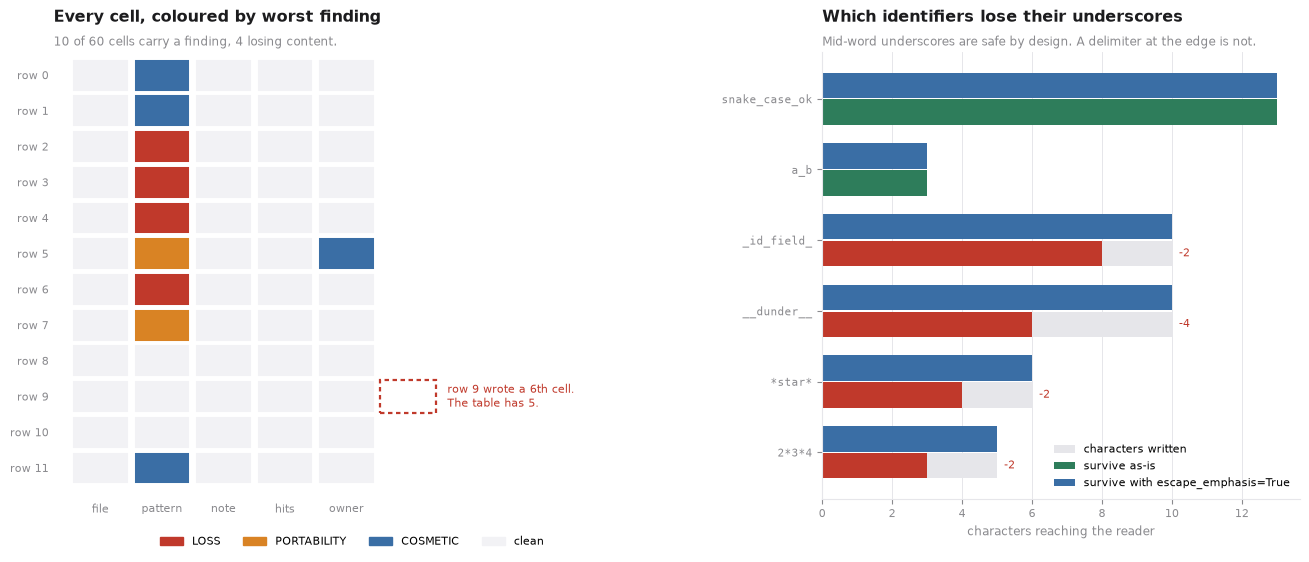

In [13]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

INK, MUTED, GRID = "#1c1c1e", "#8a8a8e", "#e6e6ea"
LOSS_C, PORT_C, COSM_C, OK_C, PALE = "#c0392b", "#d98324", "#3a6ea5", "#2e7d5b", "#f2f2f5"
SEV_COLOR = {LOSS: LOSS_C, PORTABILITY: PORT_C, COSMETIC: COSM_C}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6.2), facecolor="white",
                               gridspec_kw={"width_ratios": [1.25, 1]})

# left: the grid
worst = {}
for f in findings:
    if f.code == "RAGGED_EXTRA":
        continue
    k = (f.row, f.column)
    if k not in worst or SEVERITY_ORDER[f.severity] < SEVERITY_ORDER[worst[k]]:
        worst[k] = f.severity
nrow, ncol = len(ROWS), len(HEADERS)
for r in range(nrow):
    for c, col in enumerate(HEADERS):
        ax1.add_patch(mpatches.Rectangle(
            (c, nrow - 1 - r), 0.92, 0.92,
            facecolor=SEV_COLOR.get(worst.get((r, col)), PALE),
            edgecolor="white", linewidth=1.4))
ax1.add_patch(mpatches.Rectangle((ncol, nrow - 10), 0.92, 0.92, facecolor="white",
                                 edgecolor=LOSS_C, linewidth=1.6, linestyle=(0, (2, 1.6))))
ax1.text(ncol + 1.1, nrow - 10 + 0.46, "row 9 wrote a 6th cell.\nThe table has 5.",
         fontsize=8, color=LOSS_C, va="center")
ax1.set_xlim(-0.3, ncol + 4.4); ax1.set_ylim(-0.4, nrow + 0.1)
ax1.set_xticks([c + 0.46 for c in range(ncol)]); ax1.set_xticklabels(HEADERS, fontsize=8)
ax1.set_yticks([nrow - 1 - r + 0.46 for r in range(nrow)])
ax1.set_yticklabels(["row %d" % r for r in range(nrow)], fontsize=7.6)
for s in ax1.spines.values():
    s.set_visible(False)
ax1.tick_params(length=0, colors=MUTED)
ax1.set_title("Every cell, coloured by worst finding", fontsize=11.5, fontweight="bold",
              color=INK, loc="left", pad=22)
ax1.text(0, 1.015, "%d of %d cells carry a finding, %d losing content."
         % (len(worst), nrow * ncol, sum(1 for v in worst.values() if v == LOSS)),
         transform=ax1.transAxes, fontsize=8.5, color=MUTED)
ax1.legend(handles=[mpatches.Patch(color=LOSS_C, label="LOSS"),
                    mpatches.Patch(color=PORT_C, label="PORTABILITY"),
                    mpatches.Patch(color=COSM_C, label="COSMETIC"),
                    mpatches.Patch(color=PALE, label="clean")],
           loc="upper center", bbox_to_anchor=(0.5, -0.06), ncol=4, frameon=False, fontsize=8.2)

# right: identifiers
ids = ["snake_case_ok", "a_b", "_id_field_", "__dunder__", "*star*", "2*3*4"]
written = [len(s) for s in ids]
if HAVE_PARSER:
    kept = [len(one_cell(escape_cell(s))) for s in ids]
    fixed = [len(one_cell(escape_cell(s, escape_emphasis=True))) for s in ids]
else:
    kept = fixed = written
y = range(len(ids))
ax2.barh([i + 0.19 for i in y], written, height=0.36, color=GRID, label="characters written")
ax2.barh([i + 0.19 for i in y], kept, height=0.36,
         color=[OK_C if k == w else LOSS_C for k, w in zip(kept, written)], label="survive as-is")
ax2.barh([i - 0.19 for i in y], fixed, height=0.36, color=COSM_C,
         label="survive with escape_emphasis=True")
for i, (w, k) in enumerate(zip(written, kept)):
    if k != w:
        ax2.text(w + 0.2, i + 0.19, "-%d" % (w - k), va="center", fontsize=7.6, color=LOSS_C)
ax2.set_yticks(list(y)); ax2.set_yticklabels(ids, fontsize=8.2, family="monospace")
ax2.invert_yaxis(); ax2.grid(axis="x", color=GRID, linewidth=0.7); ax2.set_axisbelow(True)
ax2.set_xlabel("characters reaching the reader", fontsize=8.4, color=MUTED)
for s in ("top", "right"):
    ax2.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax2.spines[s].set_color(GRID)
ax2.tick_params(colors=MUTED, labelsize=8.2)
ax2.legend(frameon=False, fontsize=7.6, loc="lower right")
ax2.set_title("Which identifiers lose their underscores", fontsize=11.5, fontweight="bold",
              color=INK, loc="left", pad=22)
ax2.text(0, 1.015, "Mid-word underscores are safe by design. A delimiter at the edge is not.",
         transform=ax2.transAxes, fontsize=8.5, color=MUTED)

fig.subplots_adjust(left=0.09, right=0.98, top=0.86, bottom=0.14, wspace=0.32)
fig.savefig("notebook_audit.png", dpi=120, facecolor="white")
plt.show()

## What the tool actually decides

Three of the seven findings have no fix inside a markdown table, and the honest move is to say so
rather than silently substitute something:

- **`EDGE_SPACE`** - there is no escape for leading whitespace. A code span preserves it but changes
  how the cell looks, and that is a visual decision about somebody else's table.
- **`NEWLINE`** - every option leaves markdown or loses the break. The severity therefore depends on
  the *policy chosen*, not on the data: `PORTABILITY` under `<br>`, `LOSS` under a flatten.
- **`RAGGED_EXTRA`** - the content never enters the table, so no amount of escaping helps. This is
  the finding that justifies auditing before the render rather than diffing after it.

The four that do have fixes get them: pipes are escaped with a backslash rather than an entity,
emphasis is escapable on request, padding uses display columns, and alignment is inferred per
column because GFM has no per-cell alignment to infer.

## Try your own

In [14]:
# Paste your own rows here. A DataFrame goes in as:
#     render(df.values.tolist(), df.columns)
#
# my_headers = ["column", "type", "note"]
# my_rows = [
#     ["user_id",     "bigint", "primary key"],
#     ["_meta_",      "json",   "underscores at both ends"],
#     ["price|local", "text",   "a pipe, in a code span: `price|local`"],
#     ["  indented",  "text",   "leading spaces"],
#     ["extra",       "text",   "note", "A FOURTH CELL"],
# ]
#
# table, findings = render(my_rows, my_headers)
# print(table)
# print()
# for f in findings:
#     print("%-15s %-12s %-8s %s" % (f.code, f.severity, f.where, f.detail))
#
# # ...and with the emphasis escaper on:
# table2, findings2 = render(my_rows, my_headers, escape_emphasis=True)
# print(table2)

---

**Day 140** of the [phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder) portfolio.

For the interactive version - paste a CSV, pick the policies, watch the findings change - run the
Streamlit app:

```bash
pip install -r requirements.txt
streamlit run app.py
```

To reproduce the evidence and the tests from the command line:

```bash
python3 evidence.py      # every claim above, round-tripped through a parser
python3 test_tabler.py   # 38 tests, no pytest required
```